In [1]:
import pandas as pd

# membaca file excel
df = pd.read_excel("jte_1778068387594.xlsx")

# menampilkan 5 data pertama
print(df.head())

# informasi data
print(df.info())

# cek data kosong
print(df.isnull().sum())

      BULAN        PENDAPATAN           BIAYA            LABA
0   Januari  Rp 1.080.000.000  Rp 792.222.753  Rp 287.777.247
1  Februari    Rp 460.270.500  Rp 393.266.121   Rp 67.004.379
2     Maret  Rp 1.439.607.900  Rp 777.396.331  Rp 662.211.569
3     April  Rp 1.000.657.495  Rp 378.717.990  Rp 621.939.505
4       Mei      Rp 4.632.000    Rp 2.780.320    Rp 1.851.680
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 196 entries, 0 to 195
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype 
---  ------      --------------  ----- 
 0   BULAN       192 non-null    object
 1   PENDAPATAN  187 non-null    object
 2   BIAYA       17 non-null     object
 3   LABA        16 non-null     object
dtypes: object(4)
memory usage: 6.2+ KB
None
BULAN           4
PENDAPATAN      9
BIAYA         179
LABA          180
dtype: int64


In [2]:
# menampilkan nama semua kolom
print(df.columns)

# ukuran data
print(df.shape)

# statistik data angka
print(df.describe())

Index(['BULAN', 'PENDAPATAN', 'BIAYA', 'LABA'], dtype='object')
(196, 4)
             BULAN      PENDAPATAN           BIAYA  LABA
count          192             187              17    16
unique         110              82              16    11
top     uang masuk  Rp 200.000.000  Rp 792.222.753  Rp 0
freq            15               9               2     4


In [3]:
# membersihkan format rupiah menjadi angka

df["PENDAPATAN"] = (
    df["PENDAPATAN"]
    .astype(str)
    .str.replace("Rp", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["BIAYA"] = (
    df["BIAYA"]
    .astype(str)
    .str.replace("Rp", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

df["LABA"] = (
    df["LABA"]
    .astype(str)
    .str.replace("Rp", "", regex=False)
    .str.replace(".", "", regex=False)
    .str.replace(",", "", regex=False)
    .str.strip()
)

# mengubah menjadi angka
df["PENDAPATAN"] = pd.to_numeric(df["PENDAPATAN"], errors="coerce")
df["BIAYA"] = pd.to_numeric(df["BIAYA"], errors="coerce")
df["LABA"] = pd.to_numeric(df["LABA"], errors="coerce")

# menghapus data kosong
df = df.dropna()

# cek hasil
print(df.info())

# tampilkan data awal
print(df.head())

<class 'pandas.core.frame.DataFrame'>
Index: 14 entries, 0 to 158
Data columns (total 4 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   BULAN       14 non-null     object 
 1   PENDAPATAN  14 non-null     float64
 2   BIAYA       14 non-null     float64
 3   LABA        14 non-null     float64
dtypes: float64(3), object(1)
memory usage: 560.0+ bytes
None
      BULAN    PENDAPATAN        BIAYA         LABA
0   Januari  1.080000e+09  792222753.0  287777247.0
1  Februari  4.602705e+08  393266121.0   67004379.0
2     Maret  1.439608e+09  777396331.0  662211569.0
3     April  1.000657e+09  378717990.0  621939505.0
4       Mei  4.632000e+06    2780320.0    1851680.0


In [4]:
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_absolute_error

# menentukan fitur (X)
X = df[["PENDAPATAN", "BIAYA"]]

# menentukan target (y)
y = df["LABA"]

# membagi data training dan testing
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# membuat model machine learning
model = LinearRegression()

# training model
model.fit(X_train, y_train)

# prediksi data testing
y_pred = model.predict(X_test)

# menampilkan hasil prediksi
print("Hasil Prediksi:")
print(y_pred)

# menghitung error
mae = mean_absolute_error(y_test, y_pred)

print("\nMean Absolute Error:")
print(mae)

Hasil Prediksi:
[-1.19209290e-07  1.00000000e+08  2.87777247e+08]

Mean Absolute Error:
2.384185791015625e-07


In [5]:
# membuat data baru untuk diprediksi

data_baru = pd.DataFrame({
    "PENDAPATAN": [2000000000],
    "BIAYA": [1200000000]
})

# melakukan prediksi laba
prediksi_laba = model.predict(data_baru)

# menampilkan hasil prediksi
print("Prediksi LABA:")
print(prediksi_laba)

Prediksi LABA:
[8.e+08]


Matplotlib is building the font cache; this may take a moment.


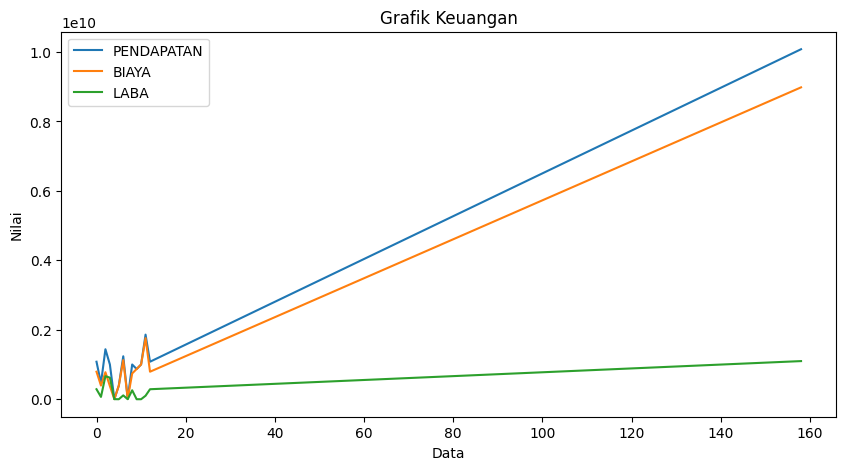

In [6]:
import matplotlib.pyplot as plt

# membuat grafik
plt.figure(figsize=(10,5))

plt.plot(df["PENDAPATAN"], label="PENDAPATAN")
plt.plot(df["BIAYA"], label="BIAYA")
plt.plot(df["LABA"], label="LABA")

# judul dan label
plt.title("Grafik Keuangan")
plt.xlabel("Data")
plt.ylabel("Nilai")

# menampilkan legenda
plt.legend()

# tampilkan grafik
plt.show()

In [7]:
# membuat beberapa data baru

data_baru_banyak = pd.DataFrame({
    "PENDAPATAN": [
        1500000000,
        2500000000,
        3000000000,
        5000000000
    ],
    
    "BIAYA": [
        800000000,
        1200000000,
        1800000000,
        3500000000
    ]
})

# melakukan prediksi
hasil_prediksi = model.predict(data_baru_banyak)

# menambahkan hasil prediksi ke tabel
data_baru_banyak["PREDIKSI_LABA"] = hasil_prediksi

# menampilkan hasil
print(data_baru_banyak)

   PENDAPATAN       BIAYA  PREDIKSI_LABA
0  1500000000   800000000   7.000000e+08
1  2500000000  1200000000   1.300000e+09
2  3000000000  1800000000   1.200000e+09
3  5000000000  3500000000   1.500000e+09


In [8]:
import joblib

# simpan model
joblib.dump(model, "model_laba.pkl")

print("Model berhasil disimpan!")

Model berhasil disimpan!


In [9]:
# load model kembali
model_baru = joblib.load("model_laba.pkl")

print("Model berhasil dibuka kembali!")

Model berhasil dibuka kembali!


In [10]:
# contoh prediksi bulan depan

forecast_bulan_depan = pd.DataFrame({
    "PENDAPATAN": [3500000000],
    "BIAYA": [2000000000]
})

# prediksi laba
hasil_forecast = model.predict(forecast_bulan_depan)

print("Forecast LABA Bulan Depan:")
print(hasil_forecast)

Forecast LABA Bulan Depan:
[1.5e+09]


In [11]:
# export hasil prediksi ke excel

data_baru_banyak.to_excel(
    "hasil_prediksi.xlsx",
    index=False
)

print("Hasil berhasil disimpan ke Excel!")

Hasil berhasil disimpan ke Excel!


In [12]:
from xgboost import XGBRegressor
from sklearn.metrics import mean_absolute_error

# membuat model XGBoost
xgb_model = XGBRegressor(
    n_estimators=100,
    learning_rate=0.1,
    max_depth=3,
    random_state=42
)

# training model
xgb_model.fit(X_train, y_train)

# prediksi
xgb_pred = xgb_model.predict(X_test)

# menghitung error
xgb_mae = mean_absolute_error(y_test, xgb_pred)

print("MAE XGBoost:")
print(xgb_mae)

ModuleNotFoundError: No module named 'xgboost'